In [1]:
!pip install kaggle

Importing Face Mask Dataset

In [19]:
import os
os.environ['KAGGLE_USERNAME'] = 'shivakumar321'
os.environ['KAGGLE_KEY'] = '33e9c68fa9f6b6af79d6b7e2cf4b2917'

In [20]:
# API to fetch the dataset from Kaggle
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
 94% 154M/163M [00:00<00:00, 1.61GB/s]
100% 163M/163M [00:00<00:00, 1.58GB/s]


In [21]:
# extracting the compessed Dataset
from zipfile import ZipFile
dataset = '/content/face-mask-dataset.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [22]:
!mkdir -p ~/.kaggle
!cp 'kaggle (1) (1).json' ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [23]:
!ls

 data	 face-mask-dataset.zip	'kaggle (1).json'   sample_data
 drive	'kaggle (1) (1).json'	 kaggle.json


**Importing the Dependencies**

In [24]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

In [25]:
with_mask_files = os.listdir('/content/data/with_mask')
print(with_mask_files[0:5])
print(with_mask_files[-5:])

['with_mask_1105.jpg', 'with_mask_3639.jpg', 'with_mask_2127.jpg', 'with_mask_3589.jpg', 'with_mask_86.jpg']
['with_mask_2719.jpg', 'with_mask_1708.jpg', 'with_mask_1952.jpg', 'with_mask_2246.jpg', 'with_mask_1710.jpg']


In [26]:
without_mask_files = os.listdir('/content/data/without_mask')
print(without_mask_files[0:5])
print(without_mask_files[-5:])

['without_mask_1469.jpg', 'without_mask_1274.jpg', 'without_mask_348.jpg', 'without_mask_3120.jpg', 'without_mask_237.jpg']
['without_mask_2831.jpg', 'without_mask_1140.jpg', 'without_mask_1228.jpg', 'without_mask_1770.jpg', 'without_mask_2637.jpg']


In [27]:
print('Number of with mask images:', len(with_mask_files))
print('Number of without mask images:', len(without_mask_files))

Number of with mask images: 3725
Number of without mask images: 3828


**Creating Labels for the two class of Images**

with mask  -->  1

without mask  -->  0

In [28]:
# create the labels

with_mask_labels = [1]*3725

without_mask_labels = [0]*3828

In [29]:
print(with_mask_labels[0:5])

print(without_mask_labels[0:5])

[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


In [30]:
print(len(with_mask_labels))
print(len(without_mask_labels))

3725
3828


In [31]:
labels = with_mask_labels + without_mask_labels

print(len(labels))
print(labels[0:5])
print(labels[-5:])

7553
[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


**Displaying the Images**

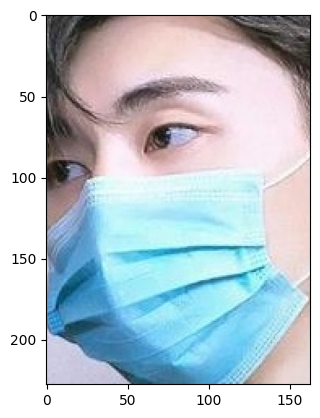

In [32]:
# displaying with mask image
img = mpimg.imread('/content/data/with_mask/with_mask_1545.jpg')
imgplot = plt.imshow(img)
plt.show()

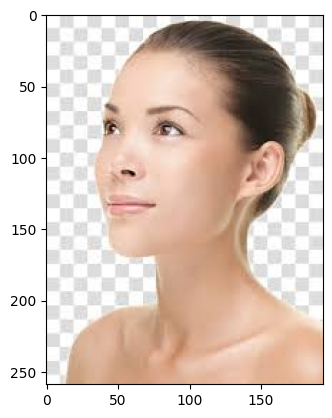

In [33]:
# displaying without mask image
img = mpimg.imread('/content/data/without_mask/without_mask_2925.jpg')
imgplot = plt.imshow(img)
plt.show()

**Image Processing**

1. Resize the Images

2. Convert the images to numpy arrays

In [34]:
# convert images to numpy arrays+

with_mask_path = '/content/data/with_mask/'

data = []

for img_file in with_mask_files:

  image = Image.open(with_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)



without_mask_path = '/content/data/without_mask/'


for img_file in without_mask_files:

  image = Image.open(without_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [35]:
type(data)

list

In [36]:
len(data)

7553

array([[[ 12,   4,  15],
        [ 10,   3,  14],
        [  6,   0,  10],
        ...,
        [142, 145, 176],
        [152, 155, 186],
        [157, 160, 191]],

       [[ 14,   5,  19],
        [ 11,   4,  17],
        [  7,   1,  13],
        ...,
        [110, 113, 144],
        [119, 122, 153],
        [125, 126, 157]],

       [[ 16,   7,  25],
        [ 13,   6,  23],
        [  8,   2,  19],
        ...,
        [ 78,  80, 111],
        [ 82,  83, 114],
        [ 84,  84, 116]],

       ...,

       [[248, 242, 242],
        [248, 242, 242],
        [248, 242, 242],
        ...,
        [240, 246, 248],
        [245, 251, 255],
        [247, 254, 255]],

       [[244, 237, 236],
        [242, 236, 235],
        [240, 233, 232],
        ...,
        [241, 245, 246],
        [242, 248, 248],
        [244, 250, 249]],

       [[242, 234, 232],
        [238, 230, 228],
        [230, 222, 220],
        ...,
        [240, 241, 243],
        [232, 236, 237],
        [228, 235, 234]]], dtype=uint8)
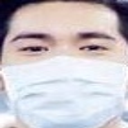

In [37]:
data[0]

In [38]:
type(data[0])

numpy.ndarray

In [39]:
data[0].shape

(128, 128, 3)

In [40]:
# converting image list and label list to numpy arrays

X = np.array(data)
Y = np.array(labels)

In [41]:
type(X)

numpy.ndarray

In [42]:
type(Y)

numpy.ndarray

In [43]:
print(X.shape)
print(Y.shape)

(7553, 128, 128, 3)
(7553,)


In [44]:
print(Y)

[1 1 1 ... 0 0 0]


**Train Test Split**

In [45]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [46]:
print(X.shape, X_train.shape, X_test.shape)

(7553, 128, 128, 3) (6042, 128, 128, 3) (1511, 128, 128, 3)


In [47]:
# scaling the data

X_train_scaled = X_train/255

X_test_scaled = X_test/255

array([[[157, 125,  95],
        [180, 145, 112],
        [186, 147, 112],
        ...,
        [167, 165, 138],
        [235, 234, 212],
        [172, 164, 129]],

       [[151, 120,  92],
        [183, 149, 118],
        [194, 155, 121],
        ...,
        [160, 158, 131],
        [220, 219, 197],
        [159, 147, 116]],

       [[148, 118,  94],
        [191, 157, 128],
        [204, 166, 133],
        ...,
        [153, 151, 123],
        [227, 226, 203],
        [152, 138, 112]],

       ...,

       [[202, 166, 145],
        [205, 170, 148],
        [200, 173, 155],
        ...,
        [184, 156, 134],
        [200, 170, 146],
        [187, 154, 129]],

       [[202, 165, 143],
        [204, 169, 147],
        [199, 172, 155],
        ...,
        [158, 130, 108],
        [196, 167, 144],
        [198, 166, 142]],

       [[205, 172, 146],
        [208, 176, 150],
        [201, 177, 157],
        ...,
        [153, 126, 105],
        [177, 149, 129],
        [192, 162, 139]]], dtype=uint8)
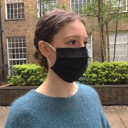

In [48]:
X_train[0]

In [49]:
X_train_scaled[0]

array([[[0.61568627, 0.49019608, 0.37254902],
        [0.70588235, 0.56862745, 0.43921569],
        [0.72941176, 0.57647059, 0.43921569],
        ...,
        [0.65490196, 0.64705882, 0.54117647],
        [0.92156863, 0.91764706, 0.83137255],
        [0.6745098 , 0.64313725, 0.50588235]],

       [[0.59215686, 0.47058824, 0.36078431],
        [0.71764706, 0.58431373, 0.4627451 ],
        [0.76078431, 0.60784314, 0.4745098 ],
        ...,
        [0.62745098, 0.61960784, 0.51372549],
        [0.8627451 , 0.85882353, 0.77254902],
        [0.62352941, 0.57647059, 0.45490196]],

       [[0.58039216, 0.4627451 , 0.36862745],
        [0.74901961, 0.61568627, 0.50196078],
        [0.8       , 0.65098039, 0.52156863],
        ...,
        [0.6       , 0.59215686, 0.48235294],
        [0.89019608, 0.88627451, 0.79607843],
        [0.59607843, 0.54117647, 0.43921569]],

       ...,

       [[0.79215686, 0.65098039, 0.56862745],
        [0.80392157, 0.66666667, 0.58039216],
        [0.78431373, 0

**Building a Convolutional Neural Networks (CNN)**

In [50]:
import tensorflow as tf
from tensorflow import keras

In [51]:
num_of_classes = 2

model = keras.Sequential()

model.add(keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(128,128,3)))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))


model.add(keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dropout(0.5))


model.add(keras.layers.Dense(num_of_classes, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [52]:
# compile the neural network
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['acc'])

In [53]:
# training the neural network
history = model.fit(X_train_scaled, Y_train, validation_split=0.1, epochs=10)

Epoch 1/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 18s 68ms/step - acc: 0.6892 - loss: 0.7443 - val_acc: 0.8893 - val_loss: 0.2752
Epoch 2/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - acc: 0.8678 - loss: 0.3239 - val_acc: 0.9074 - val_loss: 0.2280
Epoch 3/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - acc: 0.8996 - loss: 0.2558 - val_acc: 0.9256 - val_loss: 0.2020
Epoch 4/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - acc: 0.9185 - loss: 0.2088 - val_acc: 0.9273 - val_loss: 0.2030
Epoch 5/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - acc: 0.9324 - loss: 0.1624 - val_acc: 0.9322 - val_loss: 0.2152
Epoch 6/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - acc: 0.9452 - loss: 0.1315 - val_acc: 0.9174 - val_loss: 0.2276
Epoch 7/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - acc: 0.9346 - loss: 0.1538 - val_acc: 0.9273 - val_loss: 0.2654
Epoch 8/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - acc: 0.9562 - loss: 0.1097 - val_acc: 0.9421 - val_loss: 0.2133
Epoch 9/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms

**Model Evaluation**

In [54]:
loss, accuracy = model.evaluate(X_test_scaled, Y_test)
print('Test Accuracy =', accuracy)

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - acc: 0.9343 - loss: 0.2329
Test Accuracy = 0.9364659190177917


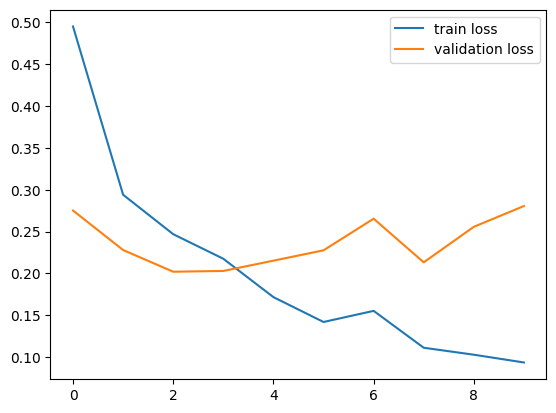

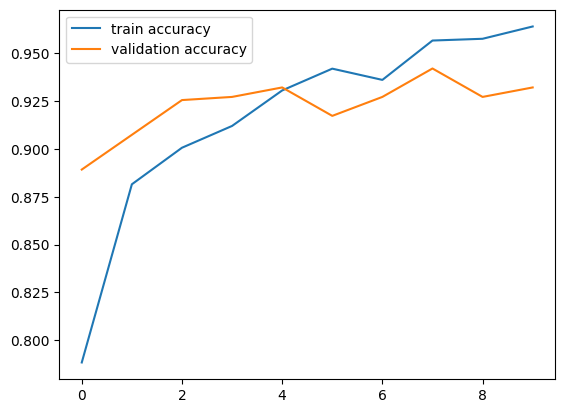

In [55]:
h = history

# plot the loss value
plt.plot(h.history['loss'], label='train loss')
plt.plot(h.history['val_loss'], label='validation loss')
plt.legend()
plt.show()

# plot the accuracy value
plt.plot(h.history['acc'], label='train accuracy')
plt.plot(h.history['val_acc'], label='validation accuracy')
plt.legend()
plt.show()

**Predictive System**

Path of the image to be predicted: /content/M Image.jpeg


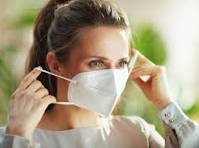

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 887ms/step
[[0.4186451  0.74333405]]
1
The person in the image is wearing a mask


In [56]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resized = cv2.resize(input_image, (128,128))

input_image_scaled = input_image_resized/255

input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3])

input_prediction = model.predict(input_image_reshaped)

print(input_prediction)


input_pred_label = np.argmax(input_prediction)

print(input_pred_label)


if input_pred_label == 1:

  print('The person in the image is wearing a mask')

else:

  print('The person in the image is not wearing a mask')

Path of the image to be predicted: /content/M Image.jpeg


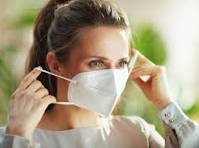

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
[[0.4186451  0.74333405]]
1
The person in the image is wearing a mask


In [57]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resized = cv2.resize(input_image, (128,128))

input_image_scaled = input_image_resized/255

input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3])

input_prediction = model.predict(input_image_reshaped)

print(input_prediction)


input_pred_label = np.argmax(input_prediction)

print(input_pred_label)


if input_pred_label == 1:

  print('The person in the image is wearing a mask')

else:

  print('The person in the image is not wearing a mask')